In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import random
import torch
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import joblib
from sklearn.decomposition import PCA
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import spearmanr, kendalltau

from model import SV_CNN

SEED = 42

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

species = "Homo_sapiens"
species_space = species.replace("_", " ")

window_size = 400
window_abbr = "0.4"
print(f"window_size: {window_size}")
half_window_size = window_size // 2
subset_str = 'combined_t'

n = 2
num_layers = f"{n}"
print(f"n: {num_layers}")

model = SV_CNN(4, 1)
if torch.cuda.is_available():
    model.to(device)
print(device)
print(model)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

data = pd.read_csv(f"{species}/{species}_balanced_data_{window_abbr}kb_annotated_{subset_str}.csv")
print(f"data.shape: {data.shape}")
print(data['chrom'].value_counts())
print(data.head())

feature_cols = ['chrom', 'sequence', 'label', 'sv_type', 'sv_len', 'pos', 'end',
       'left_start', 'left_end', 'right_start', 'right_end', 'num_del',
       'num_ins', 'num_inv', 'num_smalldel', 'num_smallins', 'gc_content',
       'full_snp_count', 'distance_to_exon', 'distance_to_Alu/SINE',
       'distance_to_L1/LINE', 'distance_to_L2/LINE', 
       'distance_to_Low_complexity/Low_complexity', 'distance_to_MIR/SINE', 'distance_to_Satellite/Satellite',
       'distance_to_Simple_repeat/Simple_repeat',
       'avg_phyloP_scores', 'avg_recomb_rate_full', 'avg_cCRE_full',
       'avg_DNase_score_full', 'avg_tf_score_full']

balanced_data = data[feature_cols].copy()
balanced_data['num_ins_del'] = balanced_data['num_ins'] + balanced_data['num_del']
balanced_data['num_small_indel'] = balanced_data['num_smallins'] + balanced_data['num_smalldel']
balanced_data.drop(['num_ins', 'num_del', 'num_smallins', 'num_smalldel', 'left_end', 'right_start'], inplace=True, axis=1)

balanced_data.rename({
    'num_small_indel': 'Number of small indels',
    'num_ins_del': 'Number of large insertions and deletions',
    'num_inv': 'Number of inversions',
    'gc_content': 'GC content',
    'distance_to_Alu/SINE': 'Distance to nearest Alu/SINE',
    'distance_to_L1/LINE': 'Distance to nearest L1/LINE',
    'distance_to_L2/LINE': 'Distance to nearest L2/LINE',
    'distance_to_MIR/SINE': 'Distance to nearest MIR/SINE',
    'distance_to_Simple_repeat/Simple_repeat': 'Distance to nearest simple repeat',
    'distance_to_exon': 'Distance to nearest exon',
    'distance_to_Satellite/Satellite': 'Distance to nearest satellite',
    'distance_to_Low_complexity/Low_complexity': 'Distance to nearest low complexity repeat',
    'avg_phyloP_scores': 'Average phyloP score',
    'full_snp_count': 'Number of SNPs',
    'avg_DNase_score_full': 'Average DNase accessibility score',
    'avg_cCRE_full': 'Average cCRE score',
    'avg_tf_score_full': 'Average transcription factor peak',
    'avg_recomb_rate_full': 'Average recombination rate'
}, axis=1, inplace=True)

print(len(balanced_data['sequence'].iloc[0]))

mapping = {'A': [1, 0, 0, 0], 'T': [0, 1, 0, 0], 'C': [0, 0, 1, 0], 'G': [0, 0, 0, 1], 'N': [0, 0, 0, 0]}

def one_hot_encode(seq, mapping):
    return np.array([mapping[ch] for ch in seq])

def get_middle(seq):
    center = len(seq) // 2
    start = max(center - 500, 0)
    end = start + 1000
    return seq[start:end]

X_categorical = np.array([one_hot_encode(seq, mapping) for seq in balanced_data['sequence']])
y = balanced_data['label'].values
indices = np.arange(len(y))

num_feature_cols = ['Number of large insertions and deletions',
       'Number of small indels', 'Number of inversions', 'GC content',
       'Number of SNPs', 'Distance to nearest exon', 'Distance to nearest Alu/SINE',
       'Distance to nearest L1/LINE', 'Distance to nearest L2/LINE', 
       'Distance to nearest low complexity repeat', 'Distance to nearest MIR/SINE', 'Distance to nearest satellite',
       'Distance to nearest simple repeat',
       'Average phyloP score', 'Average recombination rate', 'Average cCRE score',
       'Average DNase accessibility score', 'Average transcription factor peak']

X_numerical = balanced_data[num_feature_cols].astype(float).to_numpy()
print(X_categorical.shape, X_numerical.shape, y.shape)

X_train_val, X_test, y_train_val, y_test, X_num_train_val, X_num_test, train_val_idx, test_idx = train_test_split(
    X_categorical, y, X_numerical, indices, test_size=0.20, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val, X_num_train, X_num_val, train_idx, val_idx = train_test_split(
    X_train_val, y_train_val, X_num_train_val, train_val_idx, test_size=0.25, random_state=SEED, stratify=y_train_val
)

scaler = StandardScaler()
scaler.fit(X_num_train)
joblib.dump(scaler, f"{species}/{species}_{window_abbr}kb_scaler.pkl")

X_num_train_scaled = scaler.transform(X_num_train)
X_num_val_scaled = scaler.transform(X_num_val)
X_num_test_scaled = scaler.transform(X_num_test)

X_cat_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1)
X_cat_val_tensor = torch.tensor(X_val, dtype=torch.float32).permute(0, 2, 1)
X_cat_test_tensor = torch.tensor(X_test, dtype=torch.float32).permute(0, 2, 1)

X_num_train_tensor = torch.tensor(X_num_train_scaled, dtype=torch.float32)
X_num_val_tensor = torch.tensor(X_num_val_scaled, dtype=torch.float32)
X_num_test_tensor = torch.tensor(X_num_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_data = TensorDataset(X_cat_train_tensor, X_num_train_tensor, y_train_tensor)
val_data = TensorDataset(X_cat_val_tensor, X_num_val_tensor, y_val_tensor)
test_data = TensorDataset(X_cat_test_tensor, X_num_test_tensor, y_test_tensor)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
test_loader = DataLoader(test_data, batch_size=128)

print("X_cat_train_tensor.shape, X_num_train_tensor.shape, y_train_tensor.shape")
print(X_cat_train_tensor.shape, X_num_train_tensor.shape, y_train_tensor.shape)

### Non-canonical DNA structures insertions into CNN

In [ ]:
rng = random.Random(SEED)

def generate_g4_kmers(gtract_len=3, loop_range=(3, 6), num_kmers=20, min_len=30, max_len=40):
    """Generate valid G4-forming sequences (30–40 bp) with repeating GGG-loop structure."""
    bases = ['A', 'T', 'C']
    kmers = []

    for _ in range(num_kmers):
        kmer = 'G' * gtract_len  # Initial G tract
        total_len = gtract_len

        while True:
            loop_len = rng.randint(*loop_range)
            loop = ''.join(rng.choices(bases, k=loop_len))
            segment = loop + 'G' * gtract_len
            if total_len + len(segment) > max_len:
                break
            kmer += segment
            total_len += len(segment)

        kmers.append(kmer)

    return kmers

def generate_zdna_kmers(num_kmers=20, repeat_units=['CG', 'CA', 'TG'], min_len=12, max_len=18):
    """
    Generate Z-DNA-forming k-mers using mixed purine-pyrimidine dinucleotide combinations.

    Args:
        num_kmers: Number of kmers to generate.
        repeat_units: List of dinucleotide units (e.g., ['CG', 'CA', 'TG']).
        min_len: Minimum total length of the k-mer (in bp).
        max_len: Maximum total length of the k-mer (in bp).
    
    Returns:
        List of mixed Z-DNA-forming kmers.
    """
    kmers = []
    for _ in range(num_kmers):
        kmer = ''
        while len(kmer) + 2 <= max_len:
            unit = rng.choice(repeat_units)
            if len(kmer) + len(unit) > max_len:
                break
            kmer += unit

        kmers.append(kmer[:max_len])
    return kmers

def decode_one_hot(one_hot_seq):
    base_map = {0: 'A', 1: 'T', 2: 'C', 3: 'G'}
    return ''.join([base_map[np.argmax(base)] if np.sum(base) > 0 else 'N' for base in one_hot_seq.T])

def insert_kmer_and_trim(seq, kmer, pos):
    """
    Inserts a k-mer into the sequence at the specified position, then trims from both ends
    so that the sequence length is preserved and the original midpoint (breakpoint) remains
    at the center of the final sequence.

    Args:
        seq (str): Original sequence
        kmer (str): K-mer to insert
        pos (int): Index at which to insert the k-mer

    Returns:
        str: Modified sequence with the same length and original breakpoint centered
    """
    original_len = len(seq)
    mid = original_len // 2

    # Insert the kmer
    new_seq = seq[:pos] + kmer + seq[pos:]

    # Find where the original midpoint is in the new sequence
    if pos <= mid:
        shifted_mid = mid + len(kmer)
    else:
        shifted_mid = mid

    # To center the original midpoint again
    start = shifted_mid - original_len // 2
    end = start + original_len

    return new_seq[start:end]

In [ ]:
top_kmers = generate_g4_kmers(loop_range=(1, 2), num_kmers=100)

model.load_state_dict(torch.load(f"{species}/{species}_{window_abbr}kb_best_model_{num_layers}_{subset_str}.pt", map_location=torch.device(device)))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

model.eval()

results = []

with torch.no_grad():
    for X_cat, _, labels in test_loader:
        X_cat = X_cat.to(device)

        for i in range(X_cat.shape[0]):
            if labels[i].item() != 0:
                continue  # Skip if label is not 0

            original_tensor = X_cat[i].unsqueeze(0)
            original_prob = model(original_tensor).item()

            orig_seq = decode_one_hot(X_cat[i].cpu().numpy())

            for kmer in top_kmers:
                seq_len = len(orig_seq)
                mid = seq_len // 2
                k = len(kmer)
            
                # Allow any insertion position where [pos, pos + k) does NOT overlap `mid`
                valid_positions = []
                for pos in range(seq_len - k + 1):
                    if not (pos <= mid < pos + k):
                        valid_positions.append(pos)
            
                # Sample non-overlapping positions
                insertion_positions = rng.sample(valid_positions, k=50)

                for pos in insertion_positions:
                    modified_seq = insert_kmer_and_trim(orig_seq, kmer, pos)

                    one_hot_modified = one_hot_encode(modified_seq, mapping).T
                    input_tensor = torch.tensor(one_hot_modified, dtype=torch.float32).unsqueeze(0).to(device)

                    modified_prob = model(input_tensor).item()

                    results.append({
                        'insertion_position': pos,
                        'kmer': kmer,
                        'original_prob': original_prob,
                        'modified_prob': modified_prob,
                        'delta': modified_prob - original_prob,
                        'len_insertion': len(kmer)
                    })


g4_df = pd.DataFrame(results)
g4_df['kmer_type'] = 'G4'
g4_df.to_csv(f"{species}/{species}_g4_df.csv", index=False)
g4_df

cuda


,insertion_position,kmer,original_prob,modified_prob,delta,len_insertion,kmer_type
0,320,GGGAGGGAAGGGCGGGTGGGAGGGAGGGTGGGATGGG,0.062743,0.064104,0.001362,37,G4
1,47,GGGAGGGAAGGGCGGGTGGGAGGGAGGGTGGGATGGG,0.062743,0.061811,-0.000932,37,G4
2,342,GGGAGGGAAGGGCGGGTGGGAGGGAGGGTGGGATGGG,0.062743,0.057007,-0.005736,37,G4
3,343,GGGAGGGAAGGGCGGGTGGGAGGGAGGGTGGGATGGG,0.062743,0.059952,-0.002791,37,G4
4,203,GGGAGGGAAGGGCGGGTGGGAGGGAGGGTGGGATGGG,0.062743,0.186540,0.123797,37,G4
...,...,...,...,...,...,...,...
596995,32,GGGCGGGAGGGCTGGGAAGGGCGGGTAGGGAGGGTTGGG,0.056224,0.064958,0.008734,39,G4
596996,298,GGGCGGGAGGGCTGGGAAGGGCGGGTAGGGAGGGTTGGG,0.056224,0.062950,0.006726,39,G4
596997,28,GGGCGGGAGGGCTGGGAAGGGCGGGTAGGGAGGGTTGGG,0.056224,0.063890,0.007666,39,G4
596998,74,GGGCGGGAGGGCTGGGAAGGGCGGGTAGGGAGGGTTGGG,0.056224,0.074191,0.017967,39,G4


In [ ]:
# Generate random control k-mers (same count and length as G4 k-mers)
g4_kmer_lengths = [len(k) for k in top_kmers]
random_kmers_g4_length = [''.join(rng.choices(['A', 'T', 'C', 'G'], k=length)) for length in g4_kmer_lengths]
print(len(random_kmers_g4_length), random_kmers_g4_length[0])

control_results = []

with torch.no_grad():
    for X_cat, _, labels in test_loader:
        X_cat = X_cat.to(device)

        for i in range(X_cat.shape[0]):
            if labels[i].item() != 0:
                continue  # Skip if label is not 0

            original_tensor = X_cat[i].unsqueeze(0)
            original_prob = model(original_tensor).item()

            orig_seq = decode_one_hot(X_cat[i].cpu().numpy())

            for kmer in random_kmers_g4_length:
                seq_len = len(orig_seq)
                mid = seq_len // 2
                k = len(kmer)
            
                # Allow any insertion position where [pos, pos + k) does NOT overlap `mid`
                valid_positions = []
                for pos in range(seq_len - k + 1): 
                    if not (pos <= mid < pos + k):
                        valid_positions.append(pos)
            
                # Sample non-overlapping positions
                insertion_positions = rng.sample(valid_positions, k=50)

                for pos in insertion_positions:
                    modified_seq = insert_kmer_and_trim(orig_seq, kmer, pos)

                    one_hot_modified = one_hot_encode(modified_seq, mapping).T
                    input_tensor = torch.tensor(one_hot_modified, dtype=torch.float32).unsqueeze(0).to(device)

                    modified_prob = model(input_tensor).item()

                    control_results.append({
                        'insertion_position': pos,
                        'kmer': kmer,
                        'original_prob': original_prob,
                        'modified_prob': modified_prob,
                        'delta': modified_prob - original_prob,
                        'len_insertion': len(kmer)
                    })


control_df_g4 = pd.DataFrame(control_results)
control_df_g4['kmer_type'] = 'random G4-length'
control_df_g4.to_csv(f"{species}/{species}_control_df_g4.csv", index=False)
control_df_g4

100 AAACTCCTTAATAAGCGGAGATAGAATGTACTCCTAA


,insertion_position,kmer,original_prob,modified_prob,delta,len_insertion,kmer_type
0,75,AAACTCCTTAATAAGCGGAGATAGAATGTACTCCTAA,0.062743,0.053760,-0.008983,37,random G4-length
1,159,AAACTCCTTAATAAGCGGAGATAGAATGTACTCCTAA,0.062743,0.040485,-0.022258,37,random G4-length
2,257,AAACTCCTTAATAAGCGGAGATAGAATGTACTCCTAA,0.062743,0.037948,-0.024795,37,random G4-length
3,70,AAACTCCTTAATAAGCGGAGATAGAATGTACTCCTAA,0.062743,0.033554,-0.029189,37,random G4-length
4,144,AAACTCCTTAATAAGCGGAGATAGAATGTACTCCTAA,0.062743,0.037051,-0.025692,37,random G4-length
...,...,...,...,...,...,...,...
596995,31,AAGGTGACGGATAAGGGTCTGCTCGATGGATGGTGTTGA,0.056224,0.070413,0.014189,39,random G4-length
596996,361,AAGGTGACGGATAAGGGTCTGCTCGATGGATGGTGTTGA,0.056224,0.057763,0.001539,39,random G4-length
596997,42,AAGGTGACGGATAAGGGTCTGCTCGATGGATGGTGTTGA,0.056224,0.066307,0.010083,39,random G4-length
596998,240,AAGGTGACGGATAAGGGTCTGCTCGATGGATGGTGTTGA,0.056224,0.128794,0.072570,39,random G4-length


In [ ]:
zdna_kmers = generate_zdna_kmers(num_kmers=100)

model.load_state_dict(torch.load(f"{species}/{species}_{window_abbr}kb_best_model_{num_layers}_{subset_str}.pt", map_location=torch.device(device)))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

model.eval()

results = []

with torch.no_grad():
    for X_cat, _, labels in test_loader:
        X_cat = X_cat.to(device)

        for i in range(X_cat.shape[0]):
            if labels[i].item() != 0:
                continue  # Skip if label is not 0

            original_tensor = X_cat[i].unsqueeze(0)
            original_prob = model(original_tensor).item()

            orig_seq = decode_one_hot(X_cat[i].cpu().numpy())

            for kmer in zdna_kmers:
                seq_len = len(orig_seq)
                mid = seq_len // 2
                k = len(kmer)
            
                # Allow any insertion position where [pos, pos + k) does NOT overlap `mid`
                valid_positions = []
                for pos in range(seq_len - k + 1): 
                    if not (pos <= mid < pos + k):
                        valid_positions.append(pos)
            
                # Sample non-overlapping positions
                insertion_positions = rng.sample(valid_positions, k=50)

                for pos in insertion_positions:
                    modified_seq = insert_kmer_and_trim(orig_seq, kmer, pos)

                    one_hot_modified = one_hot_encode(modified_seq, mapping).T
                    input_tensor = torch.tensor(one_hot_modified, dtype=torch.float32).unsqueeze(0).to(device)

                    modified_prob = model(input_tensor).item()

                    results.append({
                        'insertion_position': pos,
                        'kmer': kmer,
                        'original_prob': original_prob,
                        'modified_prob': modified_prob,
                        'delta': modified_prob - original_prob,
                        'len_insertion': len(kmer)
                    })

zdna_df = pd.DataFrame(results)
zdna_df['kmer_type'] = 'Z-DNA'
zdna_df.to_csv(f"{species}/{species}_zdna_df.csv", index=False)
zdna_df

cuda


,insertion_position,kmer,original_prob,modified_prob,delta,len_insertion,kmer_type
0,38,CACACGTGTGTGTGTGTG,0.062743,0.058728,-0.004015,18,Z-DNA
1,306,CACACGTGTGTGTGTGTG,0.062743,0.054312,-0.008431,18,Z-DNA
2,108,CACACGTGTGTGTGTGTG,0.062743,0.039510,-0.023233,18,Z-DNA
3,329,CACACGTGTGTGTGTGTG,0.062743,0.044354,-0.018389,18,Z-DNA
4,57,CACACGTGTGTGTGTGTG,0.062743,0.040180,-0.022563,18,Z-DNA
...,...,...,...,...,...,...,...
596995,265,CGCGCGTGTGCACACACG,0.056224,0.107469,0.051244,18,Z-DNA
596996,287,CGCGCGTGTGCACACACG,0.056224,0.090690,0.034466,18,Z-DNA
596997,298,CGCGCGTGTGCACACACG,0.056224,0.122377,0.066153,18,Z-DNA
596998,153,CGCGCGTGTGCACACACG,0.056224,0.039650,-0.016574,18,Z-DNA


In [ ]:
# Generate random kmers with the same lengths
zdna_kmer_lengths = [len(k) for k in zdna_kmers]
random_kmers_zdna_length = [''.join(rng.choices(['A', 'T', 'C', 'G'], k=length)) for length in zdna_kmer_lengths]
print(len(random_kmers_zdna_length), random_kmers_zdna_length[0])

control_results_zdna = []

with torch.no_grad():
    for X_cat, _, labels in test_loader:
        X_cat = X_cat.to(device)

        for i in range(X_cat.shape[0]):
            if labels[i].item() != 0:
                continue  # Skip if label is not 0

            original_tensor = X_cat[i].unsqueeze(0)
            original_prob = model(original_tensor).item()

            orig_seq = decode_one_hot(X_cat[i].cpu().numpy())

            for kmer in random_kmers_zdna_length:
                seq_len = len(orig_seq)
                mid = seq_len // 2
                k = len(kmer)
            
                # Allow any insertion position where [pos, pos + k) does NOT overlap `mid`
                valid_positions = []
                for pos in range(seq_len - k + 1): 
                    if not (pos <= mid < pos + k):
                        valid_positions.append(pos)
            
                # Sample non-overlapping positions
                insertion_positions = rng.sample(valid_positions, k=50)

                for pos in insertion_positions:
                    modified_seq = insert_kmer_and_trim(orig_seq, kmer, pos)

                    one_hot_modified = one_hot_encode(modified_seq, mapping).T
                    input_tensor = torch.tensor(one_hot_modified, dtype=torch.float32).unsqueeze(0).to(device)

                    modified_prob = model(input_tensor).item()

                    control_results_zdna.append({
                        'insertion_position': pos,
                        'kmer': kmer,
                        'original_prob': original_prob,
                        'modified_prob': modified_prob,
                        'delta': modified_prob - original_prob,
                        'len_insertion': len(kmer)
                    })


control_df_zdna = pd.DataFrame(control_results_zdna)
control_df_zdna['kmer_type'] = 'random ZDNA-length'
control_df_zdna.to_csv(f"{species}/{species}_control_df_zdna.csv", index=False)
control_df_zdna

100 TAGGGATATGTAGAACGT


,insertion_position,kmer,original_prob,modified_prob,delta,len_insertion,kmer_type
0,310,TAGGGATATGTAGAACGT,0.062743,0.055930,-0.006813,18,random ZDNA-length
1,209,TAGGGATATGTAGAACGT,0.062743,0.046588,-0.016155,18,random ZDNA-length
2,147,TAGGGATATGTAGAACGT,0.062743,0.072363,0.009620,18,random ZDNA-length
3,66,TAGGGATATGTAGAACGT,0.062743,0.039401,-0.023341,18,random ZDNA-length
4,367,TAGGGATATGTAGAACGT,0.062743,0.073021,0.010278,18,random ZDNA-length
...,...,...,...,...,...,...,...
596995,348,ATCCCTGGATGCTCCCGA,0.056224,0.085759,0.029535,18,random ZDNA-length
596996,315,ATCCCTGGATGCTCCCGA,0.056224,0.101041,0.044817,18,random ZDNA-length
596997,78,ATCCCTGGATGCTCCCGA,0.056224,0.057970,0.001746,18,random ZDNA-length
596998,255,ATCCCTGGATGCTCCCGA,0.056224,0.081344,0.025120,18,random ZDNA-length


In [ ]:
# Combine
combined_kmer_df = pd.concat([g4_df, control_df_g4], ignore_index=True)
combined_kmer_df = pd.concat([combined_kmer_df, zdna_df], ignore_index=True)
combined_kmer_df = pd.concat([combined_kmer_df, control_df_zdna], ignore_index=True)
combined_kmer_df.to_csv(f"{species}/{species}_{window_abbr}kb_G4_ZDNA_randomkmer_{subset_str}.csv", index=False)
combined_kmer_df

,insertion_position,kmer,original_prob,modified_prob,delta,len_insertion,kmer_type
0,320,GGGAGGGAAGGGCGGGTGGGAGGGAGGGTGGGATGGG,0.062743,0.064104,0.001362,37,G4
1,47,GGGAGGGAAGGGCGGGTGGGAGGGAGGGTGGGATGGG,0.062743,0.061811,-0.000932,37,G4
2,342,GGGAGGGAAGGGCGGGTGGGAGGGAGGGTGGGATGGG,0.062743,0.057007,-0.005736,37,G4
3,343,GGGAGGGAAGGGCGGGTGGGAGGGAGGGTGGGATGGG,0.062743,0.059952,-0.002791,37,G4
4,203,GGGAGGGAAGGGCGGGTGGGAGGGAGGGTGGGATGGG,0.062743,0.186540,0.123797,37,G4
...,...,...,...,...,...,...,...
2387995,348,ATCCCTGGATGCTCCCGA,0.056224,0.085759,0.029535,18,random ZDNA-length
2387996,315,ATCCCTGGATGCTCCCGA,0.056224,0.101041,0.044817,18,random ZDNA-length
2387997,78,ATCCCTGGATGCTCCCGA,0.056224,0.057970,0.001746,18,random ZDNA-length
2387998,255,ATCCCTGGATGCTCCCGA,0.056224,0.081344,0.025120,18,random ZDNA-length


In [ ]:
# Compute average delta per (kmer, kmer_type)
avg_delta = combined_kmer_df.groupby(['kmer', 'kmer_type'])['delta'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(6, 4), sharey=True)

# G4 vs random G4-length
sns.boxplot(
    data=avg_delta[avg_delta['kmer_type'].isin(['G4', 'random G4-length'])],
    x='kmer_type',
    y='delta',
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('G4 vs Random G4-length')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean Δ Probability')

# Z-DNA vs random ZDNA-length
sns.boxplot(
    data=avg_delta[avg_delta['kmer_type'].isin(['Z-DNA', 'random ZDNA-length'])],
    x='kmer_type',
    y='delta',
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title('Z-DNA vs Random ZDNA-length')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
    
plt.tight_layout()
plt.savefig(f"{species}/{species}_{window_abbr}kb_ZDNA_vs_random_box_{subset_str}.pdf", format='pdf', bbox_inches='tight', dpi=300)
plt.show()

### K-mer embeddings

In [ ]:
from sklearn.decomposition import PCA
from transformers import AutoTokenizer, BertModel
SEED = 42
rng = random.Random(SEED)

In [ ]:
# CONFIG
USE_FIXED_K = True
FIXED_K = 12
K_RANGE = (6, 12)
NUM_KMERS = 2000 # how many random kmers to test
POSITIONS_PER_SEQ = 30 # how many insertion positions per background sequence
BATCH_LIMIT = 3
MODEL_NAME = "zhihan1996/DNABERT-2-117M"

DNA = "ACGT"
VALID = set(DNA)
sixmer_re = re.compile(r"^[ACGT]{6}$")

def generate_random_kmers(n=NUM_KMERS, use_fixed_k=USE_FIXED_K, k=FIXED_K, k_range=K_RANGE):
    kmers = set()
    if use_fixed_k:
        for _ in range(n*2):
            kmers.add("".join(rng.choices(DNA, k=k)))
            if len(kmers) >= n: break
    else:
        lo, hi = k_range
        for _ in range(n*3):
            kk = rng.randint(lo, hi)
            kmers.add("".join(rng.choices(DNA, k=kk)))
            if len(kmers) >= n: break
    return sorted(kmers)

# DNABERT token embedding
tok = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=False)
bert = BertModel.from_pretrained(MODEL_NAME) 
emb_matrix = bert.get_input_embeddings().weight.detach().cpu().numpy()
UNK_ID = tok.unk_token_id

def token_id_for_6mer(kmer):
    enc = tok(kmer, add_special_tokens=False)
    ids = enc["input_ids"]
    if len(ids) == 1 and ids[0] != UNK_ID:
        return ids[0]
    return None

def embed_kmer(kmer):
    kmer = kmer.upper()
    if not set(kmer) <= VALID: return None
    k = len(kmer)
    if k == 6 and sixmer_re.match(kmer):
        tid = token_id_for_6mer(kmer)
        return None if tid is None else emb_matrix[tid]
    if k > 6:
        toks = [kmer[i:i+6] for i in range(k-6+1)]
        ids = [token_id_for_6mer(t) for t in toks]
        ids = [i for i in ids if i is not None]
        return None if not ids else emb_matrix[ids].mean(axis=0)
    return None

def decode_one_hot(one_hot_seq):
    base_map = {0: 'A', 1: 'T', 2: 'C', 3: 'G'}
    return ''.join([base_map[np.argmax(base)] if np.sum(base) > 0 else 'N' for base in one_hot_seq.T])

In [ ]:
model.load_state_dict(torch.load(f"{species}/{species}_{window_abbr}kb_best_model_{num_layers}_{subset_str}.pt", map_location=torch.device(device)))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

rand_kmers = generate_random_kmers()
print(len(rand_kmers))
print(rand_kmers[:5])

# Run perturbations & collect delta prob per k-mer
results = []
count_batches = 0

with torch.no_grad():
    for X_cat, _, labels in test_loader:
        X_cat = X_cat.to(device)
        for i in range(X_cat.shape[0]):
            if labels[i].item() != 0:
                continue  # only background windows
            
            # original prob
            original_tensor = X_cat[i].unsqueeze(0)
            original_prob = float(model(original_tensor).item())
            orig_seq = decode_one_hot(X_cat[i].detach().cpu().numpy())

            seq_len = len(orig_seq) 
            mid = seq_len // 2

            # precompute available positions for each kmer length
            for kmer in rand_kmers:
                k = len(kmer)
                if k > seq_len: 
                    continue
                valid_positions = [pos for pos in range(seq_len - k + 1) if not (pos <= mid < pos + k)]
                if len(valid_positions) == 0:
                    continue
                
                # sample up to POSITIONS_PER_SEQ positions
                npos = min(POSITIONS_PER_SEQ, len(valid_positions))
                insertion_positions = rng.sample(valid_positions, k=npos)

                for pos in insertion_positions:
                    modified_seq = insert_kmer_and_trim(orig_seq, kmer, pos)
                    one_hot_modified = one_hot_encode(modified_seq, mapping).T
                    input_tensor = torch.tensor(one_hot_modified, dtype=torch.float32).unsqueeze(0).to(device)
                    modified_prob = float(model(input_tensor).item())

                    results.append({
                        "kmer": kmer,
                        "len": k,
                        "pos": pos,
                        "original_prob": original_prob,
                        "modified_prob": modified_prob,
                        "delta": modified_prob - original_prob
                    })

        count_batches += 1
        if count_batches >= BATCH_LIMIT:
            break

rand_df = pd.DataFrame(results)

# Aggregate to one point per k-mer
kmer_effects = (rand_df
                .groupby("kmer", as_index=False)
                .agg(delta_mean=("delta","mean"),
                     delta_median=("delta","median"),
                     n=("delta","size"),
                     klen=("len","first")))

# Embed k-mers with DNABERT token vectors
vecs = []
keep = []
for kmer in kmer_effects["kmer"]:
    v = embed_kmer(kmer)
    if v is not None:
        vecs.append(v); keep.append(True)
    else:
        keep.append(False)

kmer_effects = kmer_effects.loc[keep].reset_index(drop=True)
X = np.vstack(vecs)

kmer_effects.to_csv(f"{species}/{species}_{window_abbr}kb_{FIXED_K}kmer_deltas_pca.csv", index=False)

In [ ]:
kmer_effects = pd.read_csv(f"{species}/{species}_{window_abbr}kb_{FIXED_K}kmer_deltas_pca.csv")

# Embed k-mers with DNABERT token vectors
vecs = []
keep = []
for kmer in kmer_effects["kmer"]:
    v = embed_kmer(kmer)
    if v is not None:
        vecs.append(v); keep.append(True)
    else:
        keep.append(False)

kmer_effects = kmer_effects.loc[keep].reset_index(drop=True)
X = np.vstack(vecs)

pca = PCA(n_components=4, random_state=SEED)
XP = pca.fit_transform(X)

kmer_effects["pc1"] = XP[:, 0]
kmer_effects["pc2"] = XP[:, 1]
kmer_effects["pc3"] = XP[:, 2]
kmer_effects["pc4"] = XP[:, 3]

norm = TwoSlopeNorm(vcenter=0.0,
                    vmin=kmer_effects["delta_mean"].min(),
                    vmax=kmer_effects["delta_mean"].max())

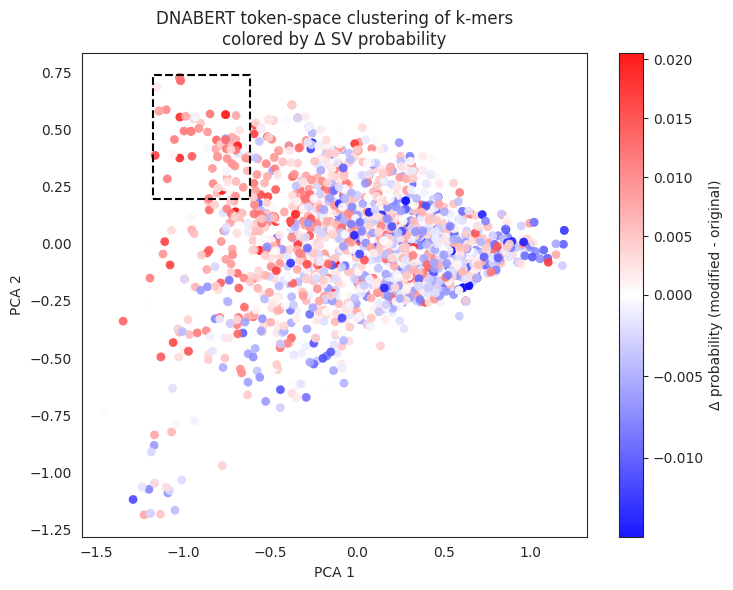

In [ ]:
# PCA plot: PC1 vs PC2
plt.figure(figsize=(7.5,6))

sc = plt.scatter(
    kmer_effects["pc1"], kmer_effects["pc2"],
    c=kmer_effects["delta_mean"], cmap="bwr", norm=norm,
    s=40, alpha=0.9, linewidths=0
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("DNABERT token-space clustering of k-mers\ncolored by Δ SV probability")
cbar = plt.colorbar(sc)
cbar.set_label("Δ probability (modified - original)")

# Identify outliers
outliers = kmer_effects[
    (kmer_effects["pc1"] < -0.6) &
    (kmer_effects["pc2"] > 0.2)
]

xmin = outliers["pc1"].min()
xmax = outliers["pc1"].max()
ymin = outliers["pc2"].min()
ymax = outliers["pc2"].max()

pad_x = 0.02 * (xmax - xmin)
pad_y = 0.02 * (ymax - ymin)

xmin -= pad_x
xmax += pad_x
ymin -= pad_y
ymax += pad_y

plt.plot(
    [xmin, xmax, xmax, xmin, xmin],
    [ymin, ymin, ymax, ymax, ymin],
    linestyle="--",
    color="black",
    linewidth=1.5
)

plt.tight_layout()
plt.savefig(
    f"{species}/{species}_{window_abbr}kb_{FIXED_K}kmer_deltas_pca_border_labeled.pdf",
    format='pdf', bbox_inches='tight', dpi=300
)
plt.show()

In [ ]:
outlier_table = kmer_effects[
    (kmer_effects["pc1"] < -0.6) &
    (kmer_effects["pc2"] > 0.20)
    ][["kmer", "pc1", "pc2", "delta_mean"]]

outlier_table = outlier_table.sort_values("delta_mean", ascending=False)

def gc_content(seq):
    seq = seq.upper()
    return (seq.count("G") + seq.count("C")) / len(seq)

def cpg_count(seq):
    return seq.upper().count("CG")

def add_kmer_metrics(df):
    df["GC content"] = df["kmer"].apply(gc_content)
    df["CpG count"] = df["kmer"].apply(cpg_count)
    return df
kmer_effects = add_kmer_metrics(kmer_effects)

outlier_table = kmer_effects[
    (kmer_effects["pc1"] < -0.6) &
    (kmer_effects["pc2"] > 0.2)
    ].copy()

outlier_table.to_csv(f"{species}/{species}_{window_abbr}kb_{FIXED_K}kmer_deltas_pca_outliers.csv", index=False)

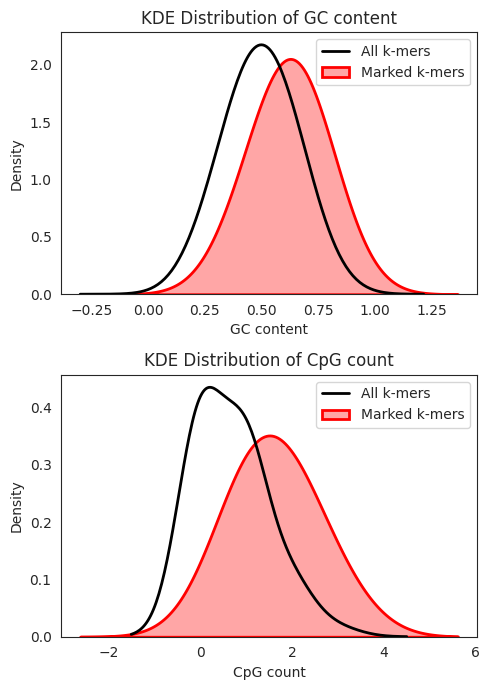

In [ ]:
features = ["GC content", "CpG count"]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(5,7))

for ax, feat in zip(axes, features):
    sns.kdeplot(
        data=kmer_effects,
        x=feat,
        lw=2,
        color="black",
        fill=False,
        bw_adjust=3,
        label="All k-mers",
        ax=ax
    )

    sns.kdeplot(
        data=outlier_table,
        x=feat,
        lw=2,
        color="red",
        fill=True,
        alpha=0.35,
        bw_adjust=3,
        label="Marked k-mers",
        ax=ax
    )

    ax.set_title(f"KDE Distribution of {feat}")
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(False)

plt.tight_layout()
plt.savefig(f"{species}/{species}_{window_abbr}kb_{FIXED_K}kmer_outlier_disttributions.pdf",
            format='pdf', bbox_inches='tight', dpi=300)
plt.show()


### Empirical homology of k-mers across breakpoints

In [ ]:
# Parameters
k = 20  # length of k-mer
seq_len = 400
half_len = seq_len // 2

similarity_counts = {0: defaultdict(int), 1: defaultdict(int)}

def compute_similarity(kmer1, kmer2):
    max_sim = 0
    for offset in range(-len(kmer1)+1, len(kmer1)):
        sim = 0
        for i in range(len(kmer1)):
            j = i + offset
            if 0 <= j < len(kmer2) and kmer1[i] == kmer2[j]:
                sim += 1
        max_sim = max(max_sim, sim)
    return max_sim

# Iterate over each sequence
for _, row in balanced_data.iterrows():
    seq = row['sequence']
    label = row['label']
    
    left = seq[:half_len]
    right = seq[half_len:]
    
    left_kmers = [left[i:i+k] for i in range(len(left) - k + 1)]
    right_kmers = [right[i:i+k] for i in range(len(right) - k + 1)]
    
    for lk in left_kmers:
        for rk in right_kmers:
            if len(lk) == k and len(rk) == k:
                sim = compute_similarity(lk, rk)
                similarity_counts[label][sim] += 1

df_plot = pd.DataFrame([
    {'similarity': sim, 'count': count, 'label': label}
    for label in similarity_counts
    for sim, count in similarity_counts[label].items()
])
df_plot.to_csv(f"{species}/{species}_kmer_similarity_empirical.csv", index=False)

plt.figure(figsize=(10, 6))
for label, group in df_plot.groupby('label'):
    plt.bar(group['similarity'] + 0.2 * label, group['count'], width=0.2, label=f'Label {label}')

plt.xlabel(f'Similarity Score (out of {k})')
plt.ylabel('Frequency')
plt.title(f'Distribution of Similarity Scores for k={k}')
plt.legend()
plt.tight_layout()
plt.show()

df_hist = pd.DataFrame([
    {'similarity': sim, 'label': label}
    for label, sim_dict in similarity_counts.items()
    for sim, count in sim_dict.items()
    for _ in range(count)
])

plt.figure(figsize=(6, 6))
sns.histplot(
    data=df_hist,
    x='similarity',
    hue='label',
    bins=range(k + 2),
    multiple='layer',
    palette={0: 'skyblue', 1: 'salmon'},
    alpha=0.5,
    edgecolor='black'
)

plt.xlabel(f'Similarity Score (out of {k})')
plt.ylabel('Frequency')
plt.title(f'Distribution of k-mer Pair Similarities (k={k})')
plt.tight_layout()
plt.savefig(f"{species}/{species}_{window_abbr}kb_microhomology_similarity_freq_{subset_str}.pdf", format='pdf', bbox_inches='tight', dpi=300)
plt.show()

### Microhomology insertions

In [ ]:
k_num = 10
k_str = '10'
rng = random.Random(SEED)

def insert_microhomology_pair_and_trim(seq, kmer, distance, buffer=10):
    """
    Inserts the same k-mer twice into the sequence symmetrically around the midpoint,
    one upstream and one downstream by a given distance. After insertion, trims the
    sequence equally from both ends to preserve original length, making sure not to
    trim the inserted k-mers by leaving a buffer zone.
    
    Args:
        seq (str): Original sequence (e.g., 400bp)
        kmer (str): K-mer to insert (e.g., 35bp)
        distance (int): Distance from the center (e.g., 20bp)
        buffer (int): Minimum distance from ends to avoid trimming inserted kmers

    Returns:
        str: Modified sequence with k-mer pair inserted and trimmed to original length
    """
    k = len(kmer)
    mid = len(seq) // 2
    original_len = len(seq)

    # Ensure insertion sites are far enough from sequence ends
    left_pos = max(buffer, mid - distance - k // 2)
    right_pos = min(len(seq) - buffer - k, mid + distance - k // 2)

    # Insert left and right kmers (right gets shifted after left insertion)
    new_seq = seq[:left_pos] + kmer + seq[left_pos:]
    right_pos += len(kmer) 
    new_seq = new_seq[:right_pos] + kmer + new_seq[right_pos:]

    # Calculate how much to trim
    excess = len(new_seq) - original_len
    trim_left = excess // 2
    trim_right = excess - trim_left
    trimmed_seq = new_seq[trim_left:len(new_seq) - trim_right]

    return trimmed_seq

def insert_asymmetric_microhomology_pair_and_trim(seq, kmer_left, kmer_right, distance, buffer=10):
    """
    Inserts two different k-mers into the sequence symmetrically around the midpoint:
    - `kmer_left` is inserted upstream of the midpoint by a specified distance
    - `kmer_right` is inserted downstream of the midpoint by the same distance

    After insertion, trims from both ends to maintain original sequence length.

    Args:
        seq (str): Original sequence
        kmer_left (str): k-mer to insert upstream
        kmer_right (str): k-mer to insert downstream
        distance (int): Distance from the center (breakpoint)
        buffer (int): Buffer space from sequence ends to prevent overlap

    Returns:
        str: Modified sequence with insertions and trimmed to original length
    """
    k_left = len(kmer_left)
    k_right = len(kmer_right)
    mid = len(seq) // 2
    original_len = len(seq)

    # Compute insertion positions
    left_pos = max(buffer, mid - distance - k_left // 2)
    right_pos = min(len(seq) - buffer - k_right, mid + distance - k_right // 2)

    # Insert left k-mer
    new_seq = seq[:left_pos] + kmer_left + seq[left_pos:]
    right_pos += len(kmer_left)
    new_seq = new_seq[:right_pos] + kmer_right + new_seq[right_pos:]

    # Trim to maintain original length
    excess = len(new_seq) - original_len
    trim_left = excess // 2
    trim_right = excess - trim_left
    trimmed_seq = new_seq[trim_left:len(new_seq) - trim_right]


    return trimmed_seq

def generate_kmer_with_exact_similarity(kmer_a, match_count):
    """Generate a k-mer_b of same length as kmer_a with exactly `match_count` matches."""
    k = len(kmer_a)

    match_indices = rng.sample(range(k), match_count)
    kmer_b = []
    for i in range(k):
        if i in match_indices:
            kmer_b.append(kmer_a[i])
        else:
            kmer_b.append(rng.choice([b for b in 'ATCG' if b != kmer_a[i]]))
    return ''.join(kmer_b)

def generate_random_kmer(k):
    """Generate a random k-mer of length k using A, T, C, G."""
    return ''.join(rng.choices('ATCG', k=k))

def decode_one_hot(one_hot_seq):
    base_map = {0: 'A', 1: 'T', 2: 'C', 3: 'G'}
    return ''.join([base_map[np.argmax(base)] if np.sum(base) > 0 else 'N' for base in one_hot_seq.T])


random_kmers = [generate_random_kmer(k_num) for _ in range(100)]

In [ ]:
model.load_state_dict(torch.load(f"{species}/{species}_{window_abbr}kb_best_model_{num_layers}_{subset_str}.pt", map_location=torch.device(device)))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

model.eval()

range_results = []
count = 0
k = 50

kmer_len = len(random_kmers[0])

with torch.no_grad():
    for X_cat, _, labels in test_loader:
        X_cat = X_cat.to(device)

        for i in range(X_cat.shape[0]):
            if labels[i].item() != 0:
                continue  # Skip if label is not 0

            original_tensor = X_cat[i].unsqueeze(0)
            original_prob = model(original_tensor).item()

            orig_seq = decode_one_hot(X_cat[i].cpu().numpy())

            buffer = 10
            seq_len = len(orig_seq)
            mid = seq_len // 2
            max_distance = mid - (len(random_kmers[0]) // 2) - buffer
            
            # Generate k distances from center that respect buffer zones
            distances = rng.sample(range(1, max_distance), k=k)

            for kmer_a in random_kmers:
                for distance in distances:
                    # Symmetric Insertion (A/A)
                    symm_seq = insert_microhomology_pair_and_trim(orig_seq, kmer_a, distance)
                    symm_encoded = one_hot_encode(symm_seq, mapping).T
                    symm_tensor = torch.tensor(symm_encoded, dtype=torch.float32).unsqueeze(0).to(device)
                    symm_prob = model(symm_tensor).item()

                    range_results.append({
                        'kmer_a': kmer_a,
                        'kmer_b': kmer_a,
                        'insertion_type': 'symmetric',
                        'distance': distance,
                        'original_prob': original_prob,
                        'modified_prob': symm_prob,
                        'delta': symm_prob - original_prob,
                        'len_insertion': len(kmer_a),
                        'similarity': 1
                    })
                    
                # Asymmetric Insertion (A/B)    
                for match_count in range(kmer_len):  # 0 to kmer_len - 1 (exclude perfect match)
                    kmer_b = generate_kmer_with_exact_similarity(kmer_a, match_count)
                    sim_score = match_count / kmer_len
                    for distance in distances:
                        asym_seq = insert_asymmetric_microhomology_pair_and_trim(orig_seq, kmer_a, kmer_b, distance)
                        asym_encoded = one_hot_encode(asym_seq, mapping).T
                        asym_tensor = torch.tensor(asym_encoded, dtype=torch.float32).unsqueeze(0).to(device)
                        asym_prob = model(asym_tensor).item()

                        range_results.append({
                            'kmer_a': kmer_a,
                            'kmer_b': kmer_b,
                            'insertion_type': 'asymmetric',
                            'distance': distance,
                            'original_prob': original_prob,
                            'modified_prob': asym_prob,
                            'delta': asym_prob - original_prob,
                            'len_insertion': kmer_len,
                            'similarity': sim_score
                        })

        print(count)
        count += 1
        if count == 2: 
            break

range_microhomology_df = pd.DataFrame(range_results)
range_microhomology_df.to_csv(f"{species}/{species}_range_microhomology_comparisons_{k_str}mer.csv", index=False)


=== BIN-LEVEL correlation ===
Spearman (bin vs Δ mean): rho=1.0000, p=1.404e-24
[Continuous Spearman] rho=0.0125, p=7.780e-35
[Kendall tau-b] tau=0.0085, p=7.683e-35
[Concordance index] C=0.5042


/tmp/ipykernel_2146615/3804792297.py:77: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(
/tmp/ipykernel_2146615/3804792297.py:77: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.pointplot(


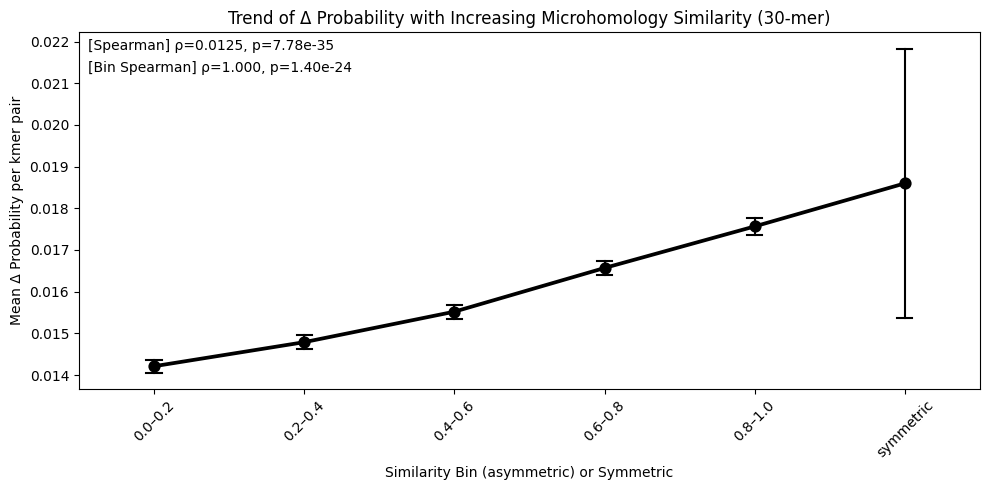

In [ ]:
for k_str in [10, 19, 22]:
    
    df = pd.read_csv(f"{species}/{species}_range_microhomology_comparisons_{k_str}mer.csv")
    
    # mean delta per (kmer_a, kmer_b, insertion_type) + counts (n)
    agg = (
        df.groupby(['kmer_a', 'kmer_b', 'insertion_type'])
          .agg(delta_mean=('delta','mean'),
               n=('delta','size'))
          .reset_index()
    )
    
    # bring in one similarity value per (kmer_a, kmer_b)
    pair_sim = (
        df[['kmer_a', 'kmer_b', 'similarity']]
          .drop_duplicates(subset=['kmer_a', 'kmer_b'])
    )
    agg = agg.merge(pair_sim, on=['kmer_a', 'kmer_b'], how='left')
    
    # Binned visualization
    bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.01]
    labels = ['0.0–0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0']
    
    agg['bin'] = pd.cut(agg['similarity'], bins=bins, labels=labels, include_lowest=True).astype(str)
    agg.loc[agg['insertion_type'] == 'symmetric', 'bin'] = 'symmetric'
    bin_order = labels + ['symmetric']
    
    asym_bins = agg[agg['insertion_type'] != 'symmetric'].copy()
    bin_numeric = pd.Series({lab: i for i, lab in enumerate(labels)})
    bin_means = (
        asym_bins.groupby('bin')['delta_mean']
                 .mean()
                 .reindex(labels)
    )
    
    bin_x = bin_numeric[labels].values
    bin_y = bin_means.values
    
    rho_bin, pval_bin = spearmanr(bin_x, bin_y)
    print(f"Spearman (bin vs Δ mean): rho={rho_bin:.4f}, p={pval_bin:.3e}")
    
    # Spearman correlation
    asym = agg[agg['insertion_type'] != 'symmetric'].dropna(subset=['similarity']).copy()
    x = asym['similarity'].values
    y = asym['delta_mean'].values
    
    rho, p_two = spearmanr(x, y, nan_policy='omit')
    p_one_spearman = p_two/2 if rho > 0 else 1 - p_two/2
    
    print(f"[Continuous Spearman] rho={rho:.4f}, p={p_one_spearman:.3e}")
    
    annot_cont = f"[Spearman] ρ={rho:.4f}, p={p_one_spearman:.2e}"
    annot_bin  = f"[Bin Spearman] ρ={rho_bin:.3f}, p={pval_bin:.2e}"
    
    plt.figure(figsize=(10, 5))
    sns.pointplot(
        data=agg, x='bin', y='delta_mean', order=bin_order,
        estimator='mean', errorbar='se', color='black',
        markers='o', join=True, capsize=0.1, errwidth=1.5
    )
    
    plt.xlabel('Similarity Bin (asymmetric) or Symmetric')
    plt.ylabel('Mean Δ Probability per kmer pair')
    plt.title(f'Trend of Δ Probability with Increasing Microhomology Similarity ({k_str}-mer)')
    plt.xticks(rotation=45)
    
    ax = plt.gca()
    ax.text(0.01, 0.98, annot_cont, transform=ax.transAxes, ha='left', va='top')
    ax.text(0.01, 0.92, annot_bin,  transform=ax.transAxes, ha='left', va='top')
    
    plt.tight_layout()
    plt.savefig(
        f"{species}/{species}_increasing_microhomology_effect_{k_str}mer.pdf",
        format='pdf', bbox_inches='tight', dpi=300
    )
    plt.show()


### K-mer enrichment vs effect

In [ ]:
from collections import Counter

k = FIXED_K

# Split sequences by label
pos_seqs = balanced_data.loc[balanced_data["label"] == 1, "sequence"]
neg_seqs = balanced_data.loc[balanced_data["label"] == 0, "sequence"]

# Count kmers in each class
def count_kmers(seqs, k):
    counter = Counter()
    for seq in seqs:
        for i in range(len(seq) - k + 1):
            kmer = seq[i:i+k]
            counter[kmer] += 1
    return counter

pos_counts = count_kmers(pos_seqs, k)
neg_counts = count_kmers(neg_seqs, k)

all_kmers = set(pos_counts.keys()) | set(neg_counts.keys())
enrichment_df = []

for kmer in all_kmers:
    pos = pos_counts.get(kmer, 0)
    neg = neg_counts.get(kmer, 0)

    ratio = ((pos + 1) / (len(pos_seqs) + 1)) / ((neg + 1) / (len(neg_seqs) + 1))

    enrichment_df.append((kmer, ratio))

enrichment_df = pd.DataFrame(enrichment_df, columns=["kmer", "enrichment_ratio"])
enrichment_df.to_csv(f"{species}/{species}_{window_abbr}kb_{FIXED_K}kmer_enrichment.csv", index=False)
enrichment_df

,kmer,enrichment_ratio
0,TAACAGATTCCC,0.400000
1,TCGCTTCTGAGC,5.000000
2,GTTGCGCTACCT,0.500000
3,GTTGAGTAAAGG,0.600000
4,TTGAATTCTTAG,0.600000
...,...,...
11945372,TCCCTGATCTAG,0.250000
11945373,AGCAGGGATCTG,0.833333
11945374,GAATGCGGATAA,0.500000
11945375,CTGGCAGGGATC,0.500000


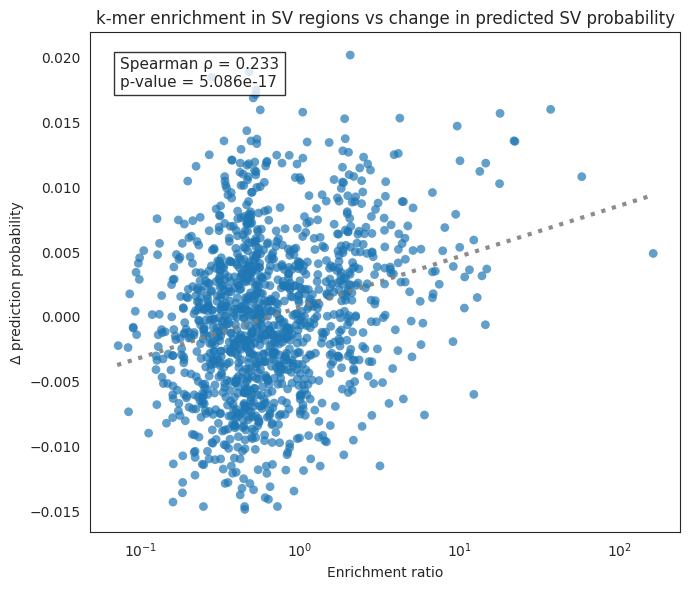

In [ ]:
kmer_effects_merged = kmer_effects.merge(enrichment_df, on="kmer", how="left")
kmer_effects_merged_valid = kmer_effects_merged[["enrichment_ratio", "delta_mean"]].dropna()

x = kmer_effects_merged_valid["enrichment_ratio"].values
y = kmer_effects_merged_valid["delta_mean"].values

# Jitter in log space
logx = np.log10(x)

jitter_strength = 0.05
logx_jittered = logx + np.random.normal(0, jitter_strength, size=len(logx))

x_jittered = 10 ** logx_jittered

# Spearman correlation
rho, pval = spearmanr(x, y)

plt.figure(figsize=(7,6))

sns.scatterplot(
    x=x_jittered,
    y=y,
    s=40,
    alpha=0.7,
    edgecolor="none"
)

plt.xscale("log")
plt.xlabel("Enrichment ratio")
plt.ylabel("Δ prediction probability")
plt.title("k-mer enrichment in SV regions vs change in predicted SV probability")

plt.text(
    0.05, 0.95,
    f"Spearman ρ = {rho:.3f}\np-value = {pval:.3e}",
    ha="left", va="top",
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.8)
)

logx_base = np.log10(x)
m, c = np.polyfit(logx_base, y, 1)
logx_line = np.linspace(logx_base.min(), logx_base.max(), 200)
x_line = 10 ** logx_line
y_line = m * logx_line + c

plt.plot(
    x_line, y_line,
    linestyle=":",
    color="grey",
    linewidth=3,
    alpha=0.9,
    label="Best-fit line"
)

plt.tight_layout()
plt.savefig(
    f"{species}/{species}_{window_abbr}kb_{FIXED_K}kmer_prob_vs_enrichment_jittered.pdf",
    format='pdf', bbox_inches='tight', dpi=300
)
plt.show()
